### 인증 + 안전장치 구축 

POST /predict/image 
인증을 통과한 사람이 이미지를 올릴 수 있고, 올린 이미지를 숫자로 분류해주는 api 서비스를 제작 


In [ ]:
import sys, os
ROOT = r"C:\Users\akals\Downloads\model-serving-course"
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
for m in [x for x in list(sys.modules) if x == "app" or x.startswith("app.")]:
    del sys.modules[m]
print("CWD:", os.getcwd())
print("found:", os.path.exists("app/model_utils.py"))

CWD: C:\Users\akals\Downloads\model-serving-course
found: True


In [28]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
import os, sys, asyncio, threading, time, socket, contextlib
import uvicorn

# 작업 디렉터리를 app/ 가 있는 위치로 맞춥니다 (notebooks/ 안에서 열어도 동작).
if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# 코드를 저장할 폴더를 미리 만들어 둡니다.
for _d in ('app', 'models', 'data', 'frontend'):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다."""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if _port_open(host, port):
        print(f'⚠️ 포트 {port}를 다른 프로세스가 사용 중입니다 (다른 노트북의 서버일 가능성).')
        print('   그 노트북에서 stop_server(8000)을 실행하거나 커널을 종료한 뒤, 이 셀을 다시 실행하세요.')
        return None
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)   # 파일을 다시 저장한 경우 최신 내용 반영
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        # Windows는 SelectorEventLoop, 그 외는 기본 이벤트 루프를 사용합니다.
        if sys.platform == 'win32':
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    for _ in range(40):
        if _port_open(host, port):
            print(f'서버 실행됨: http://{host}:{port}')
            return server
        time.sleep(0.25)
    print('서버가 시작되지 않았습니다. 위 로그를 확인하세요.')
    return server

print('서버 도우미 준비 완료 (serve_in_thread, stop_server)')

서버 도우미 준비 완료 (serve_in_thread, stop_server)


### 

인증 없는 API가 위험한 이유 >  누가 얼마나 쓰는지 모름, 모델 오남용, 아무나 무제한 호출 → 추론 비용 폭탄, 서버 마비(DoS).

API Key 방식이 ML 추론 API에 적합한 이유? > ML추론은 브라우저 로그인 방식이 아니라 코드가 코드를 부르는 상황이라 기존 로그인 방식이 적합하지 않은 것 같음 

### 검사 순서 — ① 헤더 자체가 없나? → 401, ② 있는데 목록에 없나? → 401, ③ 둘 다 통과하면 사용자 이름 반환. "없음"과 "틀림"을 따로 구분해서 메시지를 다르게

x_api_key: str = Header(None) > FastAPI가 파라미터 이름 x_api_key를 HTTP 헤더 X-API-Key에 자동으로 연결 
async def > 엔드포인트의 의존성으로 꽂힐 거라 비동기로 정의 

In [2]:
%%writefile app/auth.py
"""
Day 6 - API Key 인증
"""
from fastapi import HTTPException, Header

# 유효한 API Key 목록
# 실무에서는 환경 변수나 시크릿 매니저에서 로드합니다. 여기서는 학습용으로 하드코딩.
VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    """
    X-API-Key 헤더를 검사해 유효하면 사용자 이름을 반환한다.
    - FastAPI가 x_api_key ↔ X-API-Key 로 자동 매핑 (_ → -, 대소문자 무시)
    - Header(None): 헤더가 없으면 None 이 들어옴
    """
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )

    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )

    return VALID_API_KEYS[x_api_key]

Writing app/auth.py


### 등록된 키 확인

In [3]:
from app.auth import VALID_API_KEYS, verify_api_key

print("등록된 API Key:")
for key, user in VALID_API_KEYS.items():
    print(f"  {key} → {user}")

등록된 API Key:
  test-key-001 → 사용자A
  test-key-002 → 사용자B


### 올바른 키 확인 

In [4]:
result = await verify_api_key(x_api_key="test-key-001")
print(f"올바른 키 → 사용자: {result}")

올바른 키 → 사용자: 사용자A


### 잘못된 키 

In [5]:
from fastapi import HTTPException

try:
    await verify_api_key(x_api_key="wrong-key")
except HTTPException as e:
    print(f"잘못된 키 → {e.status_code}: {e.detail}")

잘못된 키 → 401: 유효하지 않은 API Key입니다.


### 키 없음 

In [6]:
try:
    await verify_api_key(x_api_key=None)
except HTTPException as e:
    print(f"키 없음 → {e.status_code}: {e.detail}")

키 없음 → 401: API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.


### 파일을 주고받는 방식&안전장치 

Base64 vs UploadFile. > 이미지를 어떤 방식으로 전달할 것인가. base64는 문자열을 인코딩해서 텍스트로 바꿈, 업로드 파일은 그대로 출력하는 방식임. 가벼운것을 원한다면 약간 복잡한 방식의 base64를 무거운 대신, 간단히 처리한다면 업로드 파일로 처리한다는 트레이드오프가 생길듯 

안전장치 > 이 부분은 아마 외부 보안보다는 내부 보안과 관련된 내용인가보네 인증된 사용자여도 공격은 할수 있으니까



### 안전장치 

content_type은 믿을수가 없음 이것은 클라이언트가 보낸 값이기 때문이다 exe파일을 .png로 바꾸김만 해도 이 단계는 통과가 가능하기 때문임 
await file.read()도 역시 파일을 다 읽은 뒤에 크기를 재기 때문에 파일이 서버에 끝까지 올라온 다음 거부를 해야하는 문제가 있다. 
업로드 파일의 크기가 크면클수록 손해를 보는것 같은 구조
그레이스케일은 어떤 크기가 들어오든 convert("L") 은 이미지를 흑백1채널로, 그리고 리사이즈에서 28,28로 변환만 하는데 모델 입력 규격을 맞추는 과정이고 모든 검증을 통과한 이미지만 여기 도달하게 된다. 




In [ ]:
%%writefile app/image_utils.py
"""
이미지 업로드 안전장치 + 전처리
"""
from fastapi import UploadFile, HTTPException
from PIL import Image
import io

ALLOWED_TYPES = {"image/png", "image/jpeg"}   
MAX_FILE_SIZE = 5 * 1024 * 1024  


async def validate_and_read_image(
    file: UploadFile,
    max_size: int = MAX_FILE_SIZE,
    target_size: tuple = (28, 28),
) -> Image.Image:
    """업로드 파일을 4단계로 검증하고 PIL 이미지로 반환한다."""

    # 1. 타입 검증
    if file.content_type not in ALLOWED_TYPES:
        raise HTTPException(
            status_code=400,
            detail=f"지원하지 않는 파일 형식입니다: {file.content_type}",
        )

    # 2. 크기 검증
    contents = await file.read()
    if len(contents) > max_size:
        raise HTTPException(
            status_code=400,
            detail=f"파일 크기가 {max_size // (1024*1024)}MB를 초과합니다.",
        )

    # 3. 디코딩 검증
    try:
        image = Image.open(io.BytesIO(contents))
    except Exception:
        raise HTTPException(
            status_code=400,
            detail="이미지를 읽을 수 없습니다. 파일이 손상되었을 수 있습니다.",
        )

    # 4. 리사이즈 + 그레이스케일
    image = image.convert("L").resize(target_size)

    return image

Writing app/image_utils.py


### 테스트용 가짜 이미지 만들기 

1. UploadFile vs Base64 차이? → UploadFile은 파일을 raw 바이너리 그대로(multipart) 독립 전송, Swagger에 파일 선택 버튼 자동. Base64는 바이너리를 텍스트로 인코딩해 JSON에 실어 보냄(약 33% 팽창). 파일만 올리면 UploadFile, JSON에 섞으면 Base64.

2. content_type으로 타입 검증하는 이유? → 엉뚱한 형식(.txt 등)을 싸게 거르는 1차 거름망. 단 클라이언트가 보낸 값이라 위조 가능해서, 위장 파일의 진짜 차단은 3단계 디코딩이 담당.

3. 크기 제한 안 하면? → 거대 파일로 서버 메모리·자원 고갈, 응답 지연, 최악엔 DoS로 다운.



In [8]:
from PIL import Image
import io

test_img = Image.new("L", (100, 100), color=128)   # 100x100 회색 이미지
buffer = io.BytesIO()
test_img.save(buffer, format="PNG")
test_bytes = buffer.getvalue()

print(f"테스트 이미지 크기: {len(test_bytes)} bytes")
print(f"테스트 이미지 해상도: {test_img.size}")

테스트 이미지 크기: 156 bytes
테스트 이미지 해상도: (100, 100)


### 리사이즈 확인 

In [9]:
img = Image.open(io.BytesIO(test_bytes))
img_resized = img.convert("L").resize((28, 28))
print(f"변환 전: {img.size} → 변환 후: {img_resized.size}")

변환 전: (100, 100) → 변환 후: (28, 28)


### 디코딩 검증 확인 

In [10]:
try:
    Image.open(io.BytesIO(b"this is not an image"))
except Exception as e:
    print(f"디코딩 실패: {type(e).__name__}")

디코딩 실패: UnidentifiedImageError


### 전부 합치기 
지금까지 만든 3개의 파일을 하나로 합치는 작업이다. 
요청 → ①인증 → ②검증·전처리 → ③추론 → 응답이 하나의 코드파일로 완성되는 지점이기도 함 
파일은 6개 블록으로 되어있다 
1. import
2. lifespan > 서버 켤때 모델을 로드해준다. 한번만 
3. app 생성 + 미들웨어, 에러핸들러 
4. executor + transforms — 스레드풀 + 전처리 파이프라인
5. /health
6. /predict/image — 인증·검증·추론을 꿰는 본체

lifespan은 요청마다 모델을 읽으면 속도가 많이 느려지기 때문에 한번만 읽어서 로드해두고는 모든 요청은 이걸 재사용한다. 

File(...) + Depends(...)은 한 엔드포인트에 공존하는데 FastAPI에서 아마 알아서 처리해주는것 같다. 
헤더는 verify_api_key로 요청파일의 본문은 file로 라우팅한다. 인증과 입력이 한 함수에 같이 선언된다. 

run_in_executor는 비동기 연산에서 중요한 부분이다. predict는 CPU를 점유하는 연산인데 그냥 호출하면 다른 요청을 받을수가 없기 때문에 스레드풀에 던져놓고 await로 기다리면서 추론이 도는 동안 이벤트 루프가 다른 요청을 처리한다. 


In [29]:
%%writefile app/image_api.py
"""
Day 6 - 이미지 분류 API (인증 + 파일 업로드 + MNIST 모델)
"""
import asyncio
from contextlib import asynccontextmanager
from concurrent.futures import ThreadPoolExecutor

import torch
from fastapi import FastAPI, UploadFile, File, Depends, HTTPException
from torchvision import transforms

from app.model_utils import load_model, predict, CLASS_NAMES
from app.auth import verify_api_key
from app.image_utils import validate_and_read_image
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


logger = setup_logger("image_api")

# ===== 모델 로드 =====
MODEL_PATH = "models/model.pth"   # ★함정1 — 네 파일명 (강사 노트북은 mnist_state_dict.pth)
model = None


@asynccontextmanager
async def lifespan(app: FastAPI):
    global model
    logger.info("MNIST 모델 로드 중...")
    model = load_model(MODEL_PATH)
    logger.info("모델 로드 완료")
    yield


app = FastAPI(
    title="Image Classification API",
    description="이미지를 업로드하면 숫자(0~9)를 분류하는 API (인증 필요)",
    version="1.0.0",
    lifespan=lifespan,
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="image")

# 전처리 파이프라인 (PIL → Tensor)
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])


def run_inference(tensor: torch.Tensor) -> dict:
    if model is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return predict(model, tensor)


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {"status": "healthy" if model else "loading"}


@app.post("/predict/image", tags=["Inference"])
async def predict_image(
    file: UploadFile = File(..., description="분류할 이미지 (PNG, JPEG)"),
    user: str = Depends(verify_api_key),
):
    """
    이미지를 업로드하면 숫자(0~9)를 분류합니다.
    X-API-Key 헤더에 유효한 API Key가 필요합니다.
    """
    logger.info(f"추론 요청 — 사용자: {user}, 파일: {file.filename}")

    # 1. 파일 검증 + 이미지 로드 (28x28 그레이스케일)
    image = await validate_and_read_image(file, target_size=(28, 28))

    # 2. 텐서 변환
    tensor = img_transform(image).unsqueeze(0)   # (1, 1, 28, 28)

    # 3. 비동기 추론
    try:
        loop = asyncio.get_event_loop()
        result = await loop.run_in_executor(executor, run_inference, tensor)
    except Exception as e:
        logger.error(f"추론 실패: {e}")
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    logger.info(f"추론 완료 — 결과: {result['label']}, 확신도: {result['confidence']:.2f}")  # ★함정2

    return {
        "success": True,
        "label": result["label"],          # ★함정2 — 네 predict()는 'label' 반환 (강사는 'predicted_class')
        "confidence": round(result["confidence"], 4),
        "user": user,
    }

Overwriting app/image_api.py


In [ ]:
server = serve_in_thread("app.image_api:app", port=8000)

16:19:44 | INFO    | image_api | MNIST 모델 로드 중...
16:19:44 | INFO    | image_api | 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


16:19:47 | INFO    | request | GET / → 404 (0.3ms)
16:19:47 | INFO    | request | GET /favicon.ico → 404 (0.2ms)


### 인증없이 요청 


In [31]:
import requests

response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.png", b"fake image data", "image/png")},
    # headers 없음 → 인증 실패
)

print(f"상태 코드: {response.status_code}")   # 401
print(f"응답: {response.json()}")

16:22:52 | INFO    | request | POST /predict/image → 401 (1.6ms)
상태 코드: 401
응답: {'detail': 'API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.'}


### 잘못된 키 

In [32]:
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.png", b"fake image data", "image/png")},
    headers={"X-API-Key": "wrong-key"},
)

print(f"상태 코드: {response.status_code}")   # 401
print(f"응답: {response.json()}")

16:23:24 | INFO    | request | POST /predict/image → 401 (1.2ms)
상태 코드: 401
응답: {'detail': '유효하지 않은 API Key입니다.'}


### 올바른 api로 실험해보기 


In [33]:
from torchvision import datasets
from PIL import Image
import io
import requests

# MNIST 테스트 이미지 한 장 가져오기
test_dataset = datasets.MNIST(root="data", train=False, download=True)
test_image, test_label = test_dataset[0]   # 첫 번째 테스트 이미지

# PIL 이미지 → bytes 변환
buf = io.BytesIO()
test_image.save(buf, format="PNG")
image_bytes = buf.getvalue()

print(f"테스트 이미지 정답: {test_label}")

# API 호출 (올바른 키)
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("digit.png", image_bytes, "image/png")},
    headers={"X-API-Key": "test-key-001"},
)

print(f"상태 코드: {response.status_code}")   # 200
result = response.json()
print(f"예측 결과: {result}")

테스트 이미지 정답: 7
16:25:05 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: digit.png
16:25:05 | INFO    | image_api | 추론 완료 — 결과: 7, 확신도: 1.00
16:25:05 | INFO    | request | POST /predict/image → 200 (25.9ms)
상태 코드: 200
예측 결과: {'success': True, 'label': 7, 'confidence': 1.0, 'user': '사용자A'}


### 잘못된 파일형식 

In [34]:
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.txt", b"this is not an image", "text/plain")},
    headers={"X-API-Key": "test-key-001"},
)

print(f"상태 코드: {response.status_code}")   # 400
print(f"응답: {response.json()}")

16:26:32 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: test.txt
16:26:32 | INFO    | request | POST /predict/image → 400 (1.2ms)
상태 코드: 400
응답: {'detail': "지원하지 않는 파일 형식입니다: text/plain. 허용 형식: {'image/png', 'image/jpeg'}"}


### 여러 이미지 연속 추론

In [35]:
import requests
from torchvision import datasets
import io

test_dataset = datasets.MNIST(root="data", train=False, download=True)

print("=== 연속 추론 테스트 (5장) ===\n")

for i in range(5):
    img, label = test_dataset[i]

    buf = io.BytesIO()
    img.save(buf, format="PNG")

    resp = requests.post(
        "http://localhost:8000/predict/image",
        files={"file": (f"digit_{i}.png", buf.getvalue(), "image/png")},
        headers={"X-API-Key": "test-key-001"},
    )

    r = resp.json()
    predicted = r.get("label", "?")
    confidence = r.get("confidence", 0)
    match = "✅" if str(label) == str(predicted) else "❌"

    print(f"  이미지 {i}: 정답={label}, 예측={predicted}, 확신도={confidence:.4f} {match}")

=== 연속 추론 테스트 (5장) ===

16:26:44 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: digit_0.png
16:26:44 | INFO    | image_api | 추론 완료 — 결과: 7, 확신도: 1.00
16:26:44 | INFO    | request | POST /predict/image → 200 (4.9ms)
  이미지 0: 정답=7, 예측=7, 확신도=1.0000 ✅
16:26:46 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: digit_1.png
16:26:46 | INFO    | image_api | 추론 완료 — 결과: 2, 확신도: 1.00
16:26:46 | INFO    | request | POST /predict/image → 200 (3.1ms)
  이미지 1: 정답=2, 예측=2, 확신도=0.9999 ✅
16:26:48 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: digit_2.png
16:26:48 | INFO    | image_api | 추론 완료 — 결과: 1, 확신도: 1.00
16:26:48 | INFO    | request | POST /predict/image → 200 (4.1ms)
  이미지 2: 정답=1, 예측=1, 확신도=1.0000 ✅
16:26:50 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: digit_3.png
16:26:50 | INFO    | image_api | 추론 완료 — 결과: 0, 확신도: 1.00
16:26:50 | INFO    | request | POST /predict/image → 200 (3.1ms)
  이미지 3: 정답=0, 예측=0, 확신도=1.0000 ✅
16:26:52 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: digit_4.png
16:26:52

In [ ]:
from torchvision import datasets
test_dataset = datasets.MNIST(root="data", train=False, download=True)
img, label = test_dataset[0]
img.save("test_digit.png")
print(f"test_digit.png 저장 완료 (정답: {label})")
print("→ Swagger의 Choose File에서 이 파일을 선택하세요")

test_digit.png 저장 완료 (정답: 7)
→ Swagger의 Choose File에서 이 파일을 선택하세요


16:48:09 | INFO    | request | GET /docs → 200 (0.7ms)
16:48:09 | INFO    | request | GET /openapi.json → 200 (20.3ms)
16:49:08 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: test_digit.png
16:49:08 | INFO    | image_api | 추론 완료 — 결과: 7, 확신도: 1.00
16:49:08 | INFO    | request | POST /predict/image → 200 (6.3ms)
16:49:09 | INFO    | image_api | 추론 요청 — 사용자: 사용자A, 파일: test_digit.png
16:49:09 | INFO    | image_api | 추론 완료 — 결과: 7, 확신도: 1.00
16:49:09 | INFO    | request | POST /predict/image → 200 (5.7ms)


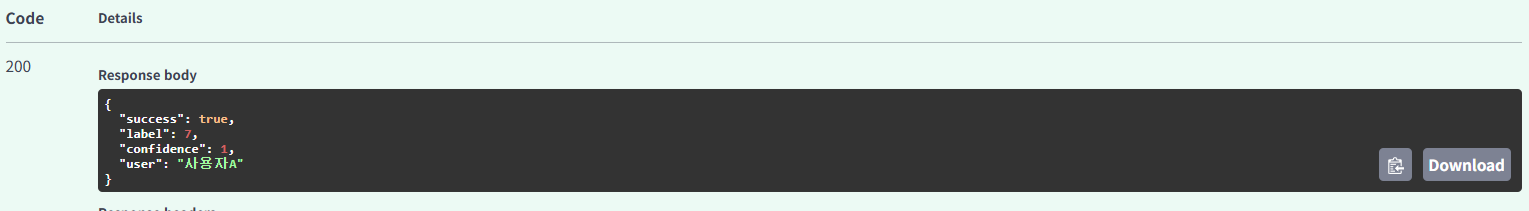

### 최종 체크포인트

1. API Key 인증이 없으면 어떤 위험이 있나? 
→ ① 누가 얼마나 쓰는지 추적이 안 되고 모델이 오남용될 수 있다.
  ② 아무나 무제한으로 호출할 수 있어 추론 비용 폭탄·서버 마비(DoS)로 이어진다.

2. Depends(verify_api_key)는 엔드포인트 실행 전에 무슨 일을 하나?
→ 엔드포인트 본체보다 먼저 verify_api_key를 실행한다. 통과하면 반환값을
  user 파라미터에 주입하고, 실패하면 본체를 실행하지 않고 401을 반환한다.


3. UploadFile이 Base64보다 편리한 점은?
→ 파일을 raw 바이너리 그대로(multipart) 보내서 Base64 같은 변환·크기 팽창(약 33%)이
  없다. 게다가 Swagger UI에 파일 선택 버튼이 자동으로 생겨 테스트가 편하다.

4. 파일 크기를 제한하지 않으면?
→ 크기가 너무 큰 파일은 서버에 부담이 된다 — 메모리·자원을 고갈시켜 응답이
  느려지거나 다운될 수 있고(한 요청이 다른 사용자까지 마비, 악의적이면 DoS),
  await file.read()는 다 읽은 뒤 크기를 재므로 거부할 파일조차 끝까지 받아야 하는
  낭비도 있다.

5. 이미지를 28×28 그레이스케일로 변환하는 이유는?
→ 전처리 과정. MNIST 모델이 흑백28×28로 학습됐으니, 입력도
  그 규격에 맞춰야 모델이 받을 수 있는 데이터가 된다.